# UNIVERSIDADE FEDERAL DO PIAUÍ – UFPI
## CAMPUS SENADOR HELVÍDIO NUNES DE BARROS – PICOS
**Curso:** Sistemas de Informação | **Período:** 6° | **Ano/Semestre:** 2026.2  
**Disciplina:** Tópicos Especiais em Visão Computacional  
**Professor:** Me. José Denes Lima Araújo  

---
# 4ª ATIVIDADE - TÉCNICAS DE FILTRAGEM ESPACIAL


### 1) O que são filtros espaciais de suavização? Quais são suas principais aplicações?

**Resposta:**

Filtros espaciais de suavização (ou filtros passa-baixa) atuam na vizinhança de cada pixel para reduzir ruídos e variações bruscas de intensidade na imagem, criando um efeito de desfoque/suavização.

Podem ser:
- **Lineares (Média e Gaussiano):** calculam a média (simples ou ponderada) dos pixels vizinhos.
- **Não-lineares (Mediana):** ordenam os pixels da vizinhança e pegam o valor central.

**Principais aplicações:**
1. **Redução de ruído:** atenuar ruído gaussiano (média/gaussiano) e eliminar ruído sal e pimenta (mediana).
2. **Pré-processamento:** suavizar a imagem antes de aplicar detecção de bordas (como Sobel ou Canny) ou segmentação, evitando detecções falsas causadas por ruídos.
3. **Junção de descontinuidades:** fechar pequenos cortes ou falhas em linhas, contornos e caracteres (OCR).
4. **Remoção de pequenos detalhes:** suavizar texturas irrelevantes de fundo para focar nas estruturas maiores.


---
### 2) Dada a seguinte imagem representada por uma matriz de pixels, informe as saídas após a aplicação dos filtros de suavização:
* a) Filtro da média, máscara 3x3 (Borda não processada e Padding por replicação).
* b) Filtro da mediana, máscara 3x3 (Borda não processada e Padding por replicação).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

# Matriz 8x8 de entrada
matriz = np.array([
    [0, 230,   0,   0,   0,   0,   0,   0],
    [0, 230,   0,   0, 210, 210, 210,   0],
    [0,   0,   0,   0, 190, 190, 210,   0],
    [0,   0,   0,   0, 190,   0, 210,   0],
    [0,   0,   0,   0, 190, 190, 210,   0],
    [0,   0,   0,   0,   0,   0,   0,   0],
    [0,   0, 190,   0,   0,   0,   0,   0],
    [0,   0,   0,   0,   0,   0,   0,   0]
], dtype=np.float32)

# Implementação manual dos filtros na matriz
def filtro_matriz(mat, tipo='media', padding='replicate'):
    H, W = mat.shape
    out = np.zeros_like(mat)
    
    if padding == 'none':
        out = mat.copy()
        for i in range(1, H - 1):
            for j in range(1, W - 1):
                janela = mat[i-1:i+2, j-1:j+2]
                out[i, j] = np.mean(janela) if tipo == 'media' else np.median(janela)
    else: # padding por replicação
        mat_pad = np.pad(mat, 1, mode='edge')
        for i in range(H):
            for j in range(W):
                janela = mat_pad[i:i+3, j:j+3]
                out[i, j] = np.mean(janela) if tipo == 'media' else np.median(janela)
    return out

# a) Filtro da Média
media_sem_borda = filtro_matriz(matriz, 'media', 'none')
media_com_pad = filtro_matriz(matriz, 'media', 'replicate')

# b) Filtro da Mediana
mediana_sem_borda = filtro_matriz(matriz, 'mediana', 'none')
mediana_com_pad = filtro_matriz(matriz, 'mediana', 'replicate')

print("a) Média 3x3 (Borda não processada):\n", np.round(media_sem_borda, 1))
print("\na) Média 3x3 (Padding replicação):\n", np.round(media_com_pad, 1))
print("\nb) Mediana 3x3 (Borda não processada):\n", mediana_sem_borda.astype(int))
print("\nb) Mediana 3x3 (Padding replicação):\n", mediana_com_pad.astype(int))


a) Média 3x3 (Borda não processada):
 [[  0.  230.    0.    0.    0.    0.    0.    0. ]
 [  0.   51.1  51.1  44.4  88.9 135.6  91.1   0. ]
 [  0.   25.6  25.6  65.6 110.  180.  114.4   0. ]
 [  0.    0.    0.   63.3 105.6 175.6 112.2   0. ]
 [  0.    0.    0.   42.2  63.3 110.   67.8   0. ]
 [  0.   21.1  21.1  42.2  42.2  65.6  44.4   0. ]
 [  0.   21.1  21.1  21.1   0.    0.    0.    0. ]
 [  0.    0.    0.    0.    0.    0.    0.    0. ]]

a) Média 3x3 (Padding replicação):
 [[ 76.7  76.7  76.7  23.3  46.7  70.   46.7  23.3]
 [ 51.1  51.1  51.1  44.4  88.9 135.6  91.1  46.7]
 [ 25.6  25.6  25.6  65.6 110.  180.  114.4  70. ]
 [  0.    0.    0.   63.3 105.6 175.6 112.2  70. ]
 [  0.    0.    0.   42.2  63.3 110.   67.8  46.7]
 [  0.   21.1  21.1  42.2  42.2  65.6  44.4  23.3]
 [  0.   21.1  21.1  21.1   0.    0.    0.    0. ]
 [  0.   21.1  21.1  21.1   0.    0.    0.    0. ]]

b) Mediana 3x3 (Borda não processada):
 [[  0 230   0   0   0   0   0   0]
 [  0   0   0   0   0 190   0  

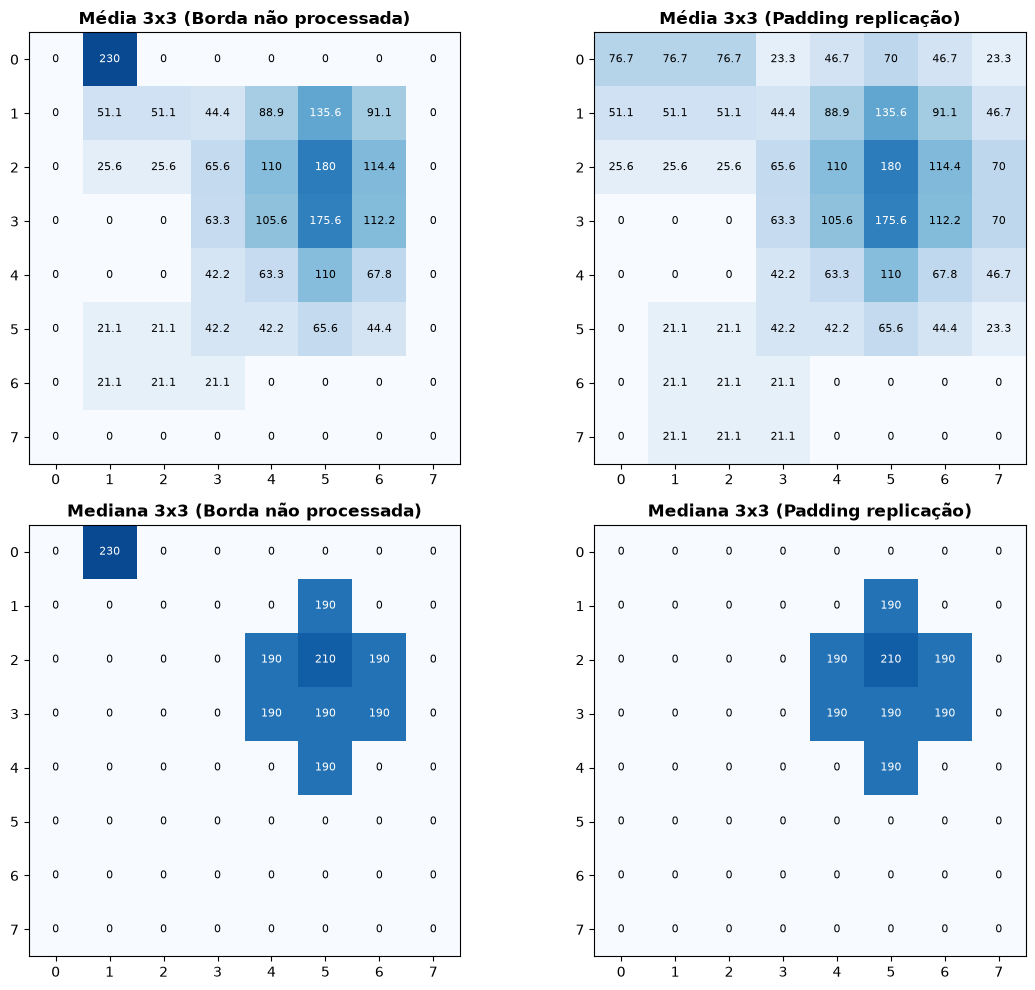

In [2]:
# Visualização gráfica das matrizes com os valores em cada pixel
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

itens = [
    (media_sem_borda, "Média 3x3 (Borda não processada)", axes[0, 0]),
    (media_com_pad, "Média 3x3 (Padding replicação)", axes[0, 1]),
    (mediana_sem_borda, "Mediana 3x3 (Borda não processada)", axes[1, 0]),
    (mediana_com_pad, "Mediana 3x3 (Padding replicação)", axes[1, 1])
]

for mat, titulo, ax in itens:
    ax.imshow(mat, cmap='Blues', vmin=0, vmax=255)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    for i in range(8):
        for j in range(8):
            val = mat[i, j]
            txt = f"{val:.0f}" if val == int(val) else f"{val:.1f}"
            cor = "white" if val > 120 else "black"
            ax.text(j, i, txt, ha='center', va='center', color=cor, fontsize=8)

plt.tight_layout()
plt.show()


---
### 3) Escolha uma imagem de sua preferência. Posteriormente, aplique os seguintes filtros de suavização usando suas respectivas máscaras 3x3, 5x5 e 7x7:
* a) Filtro da média
* b) Filtro da mediana
* c) Filtro gaussiano ($\sigma = 1$)


In [3]:
# Carregando imagem em escala de cinza
img = data.camera()

# --- IMPLEMENTAÇÃO MANUAL DOS FILTROS (100% MANUAL) ---

def media_manual(img, k):
    pad = k // 2
    img_pad = np.pad(img.astype(np.float32), pad, mode='edge')
    janelas = np.lib.stride_tricks.sliding_window_view(img_pad, (k, k))
    return np.mean(janelas, axis=(-2, -1)).astype(np.uint8)

def mediana_manual(img, k):
    pad = k // 2
    img_pad = np.pad(img.astype(np.float32), pad, mode='edge')
    janelas = np.lib.stride_tricks.sliding_window_view(img_pad, (k, k))
    return np.median(janelas, axis=(-2, -1)).astype(np.uint8)

def gaussiano_manual(img, k, sigma=1.0):
    pad = k // 2
    y, x = np.mgrid[-pad:pad+1, -pad:pad+1]
    kernel = np.exp(-(x**2 + y**2) / (2.0 * (sigma**2)))
    kernel = kernel / kernel.sum() # normalização
    
    img_pad = np.pad(img.astype(np.float32), pad, mode='edge')
    janelas = np.lib.stride_tricks.sliding_window_view(img_pad, (k, k))
    return np.clip(np.sum(janelas * kernel, axis=(-2, -1)), 0, 255).astype(np.uint8)

def mostrar(res3, res5, res7, titulo):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("Original")
    axes[1].imshow(res3, cmap='gray')
    axes[1].set_title(f"{titulo} 3x3")
    axes[2].imshow(res5, cmap='gray')
    axes[2].set_title(f"{titulo} 5x5")
    axes[3].imshow(res7, cmap='gray')
    axes[3].set_title(f"{titulo} 7x7")
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


#### a) Filtro da Média


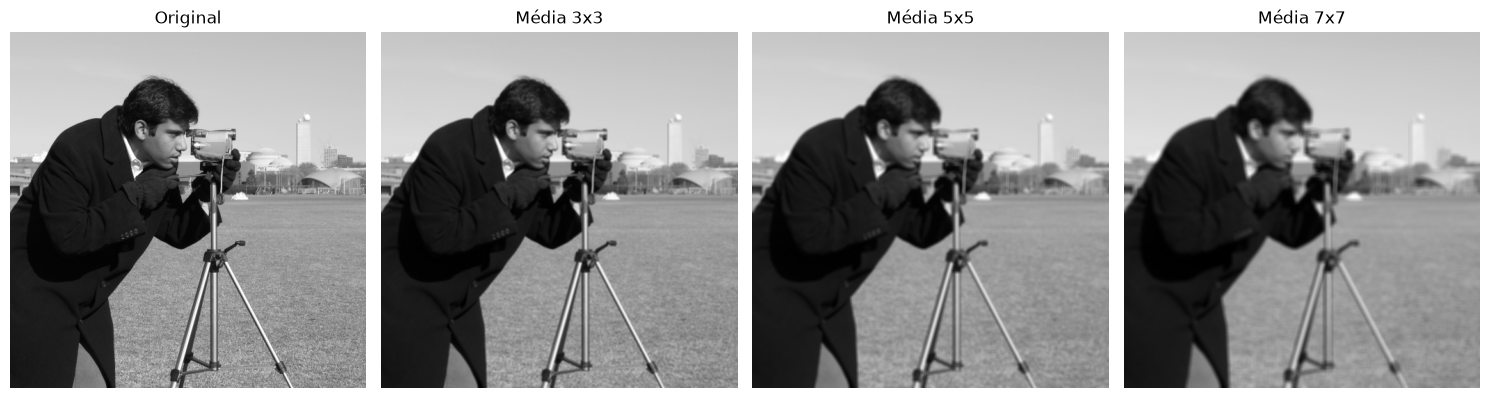

In [4]:
mostrar(media_manual(img, 3), media_manual(img, 5), media_manual(img, 7), "Média")


#### b) Filtro da Mediana


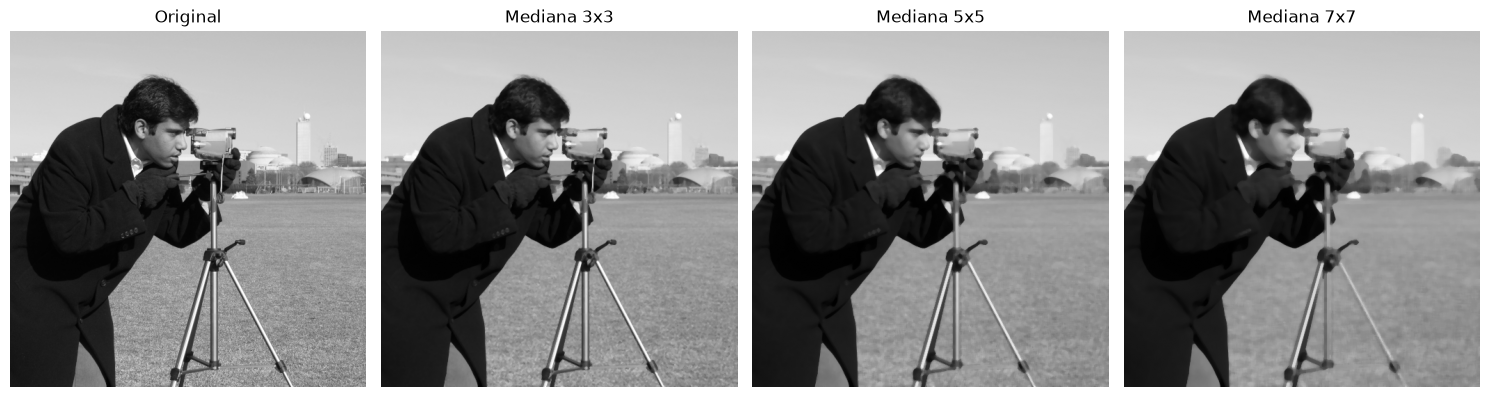

In [5]:
mostrar(mediana_manual(img, 3), mediana_manual(img, 5), mediana_manual(img, 7), "Mediana")


#### c) Filtro Gaussiano ($\sigma = 1.0$)


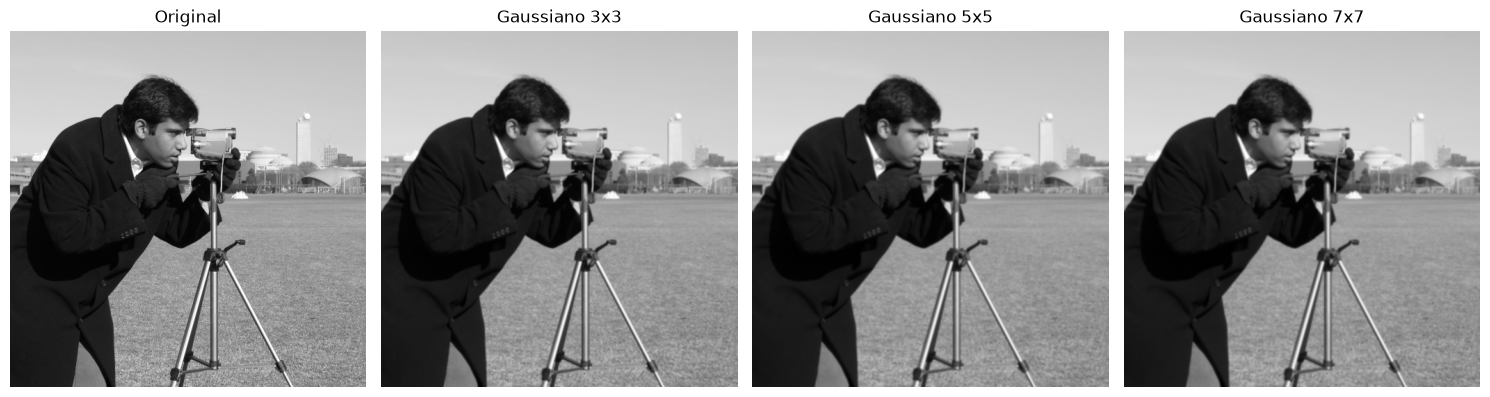

In [6]:
mostrar(gaussiano_manual(img, 3, 1.0), gaussiano_manual(img, 5, 1.0), gaussiano_manual(img, 7, 1.0), "Gaussiano")


#### Variação do parâmetro $\sigma$ no Filtro Gaussiano (máscara 7x7)


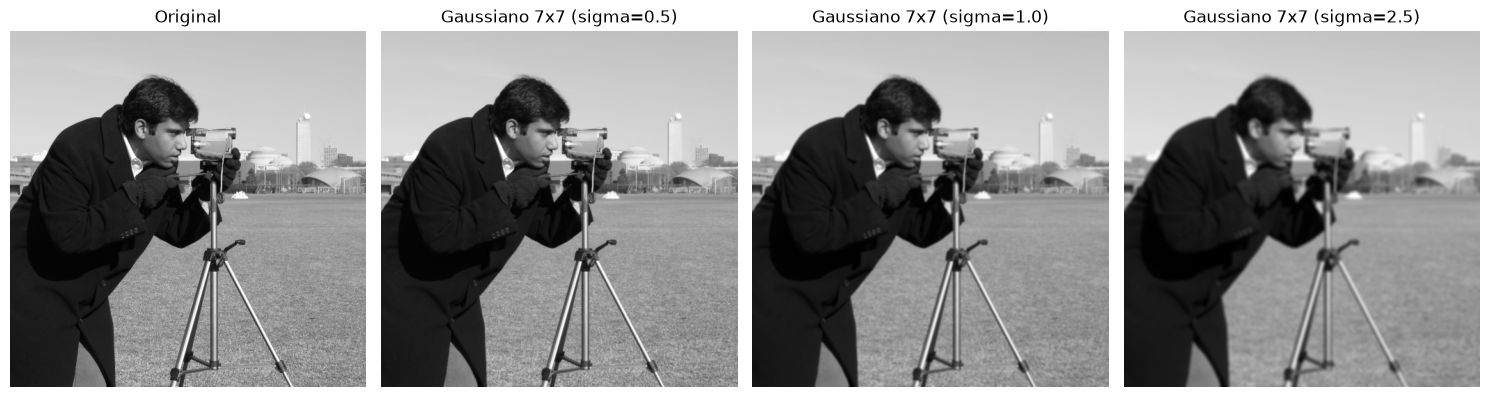

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(gaussiano_manual(img, 7, sigma=0.5), cmap='gray')
axes[1].set_title("Gaussiano 7x7 (sigma=0.5)")
axes[2].imshow(gaussiano_manual(img, 7, sigma=1.0), cmap='gray')
axes[2].set_title("Gaussiano 7x7 (sigma=1.0)")
axes[3].imshow(gaussiano_manual(img, 7, sigma=2.5), cmap='gray')
axes[3].set_title("Gaussiano 7x7 (sigma=2.5)")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
